# 67 - LSEG same-33 joined long-window strategy replay

**Question.** What happens when the immutable original-33 LSEG headline
blocks are joined and the single frozen Notebook 36 strategy is replayed
unchanged from 2024-01-01 through 2026-06-26?

This is a separately frozen post-drift-stop sensitivity analysis. The earlier
block is the primary new-information window; the full joined path is
descriptive because its later component was already opened during strategy
selection. The failed 0.80 exact-endpoint drift gate remains failed. Nothing
here can qualify as the original preregistered replication, prospective
confirmation, deployment evidence, or permission to retune.

The strategy is fixed: exact +/-1 Gemma strongest events determine activity
and counts; continuous FinBERT strongest-event ranks determine names; 25%
name cap; equal legs; one open-to-next-open interval; 10 bps per traded side;
drift-aware turnover and final liquidation.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import benjamini_hochberg  # noqa: E402
from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.joined_lseg import (  # noqa: E402
    JOIN_BOUNDARY,
    JoinedLsegInputs,
    load_joined_same33_scores,
)
from final_experiments.lib.lseg_expanded import (  # noqa: E402
    build_expanded_aggregation_panel,
    canonical_score_frame,
    load_price_exports,
    map_headlines_to_entry_sessions,
)
from final_experiments.lib.plots import (  # noqa: E402
    CATEGORICAL,
    INK,
    annotate_source,
    apply_house_style,
    zero_line,
)
from final_experiments.lib.risk_overlay import paired_block_bootstrap_difference  # noqa: E402
from final_experiments.lib.sector_portfolios import SECTOR_MEMBERS  # noqa: E402
from final_experiments.lib.sparse_spread import (  # noqa: E402
    build_exact_extrema_targets,
    ledger_rows_to_frame,
)
from sentiment_benchmark.artifact_io import sha256_file  # noqa: E402
from sentiment_benchmark.strategy_research.ledger import run_open_to_open_ledger  # noqa: E402
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402
from sentiment_benchmark.strategy_research.portfolio import (  # noqa: E402
    PositionTarget,
    TargetPortfolio,
)

SEED = 20260820
COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 5
BOOTSTRAP_REPLICATIONS = 9_999
NAME_RANDOMISATIONS = 4_999
SINGLE_NAME_CAP = 0.25
INITIAL_NAV = 1_000_000.0
MINIMUM_SESSIONS = 120
MINIMUM_ACTIVE_SESSIONS = 60
MINIMUM_ACTIVE_PER_HALF = 20

sector_members = {sector: tuple(members[:3]) for sector, members in SECTOR_MEMBERS.items()}
original_symbols = tuple(symbol for members in sector_members.values() for symbol in members)
sector_by_symbol = {
    symbol: sector for sector, members in sector_members.items() for symbol in members
}

BACKWARD_DERIVED = (
    REPO_ROOT
    / "Data/collections/lseg_us_sector_33_backward_20240101_20251026_headlines/derived"
)
SNAPSHOT = "snapshot_20260811_collection_complete"
INPUTS = JoinedLsegInputs(
    backward_finbert=(
        BACKWARD_DERIVED
        / "incremental_finbert"
        / SNAPSHOT
        / "headline_scores_finbert4556_cacheonly.csv"
    ),
    backward_gemma_seed=(
        BACKWARD_DERIVED
        / "incremental_gemma"
        / SNAPSHOT
        / "headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1_resume_seed.csv"
    ),
    backward_gemma_delta=(
        BACKWARD_DERIVED
        / "incremental_gemma"
        / SNAPSHOT
        / "headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1_delta.csv"
    ),
    recent_finbert=(
        REPO_ROOT
        / "Data/collections/lseg_us_sector_44_8m_headlines/derived/headline_scores_finbert4556_cacheonly_20260803.csv"
    ),
    recent_gemma=(
        REPO_ROOT
        / "Data/collections/lseg_us_sector_44_8m_headlines/derived/headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv"
    ),
)
PRICE_PATH = REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_2024_2026.csv"
REFERENCE_DIR = REPO_ROOT / "final_experiments/outputs/13_lseg_44_gemma_robustness"
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/67_lseg_gemma_finbert_joined_long_window"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

apply_house_style()
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Return-blind score join

Both blocks are validated against their manifests and scorer contracts before
prices are read. The later 44-company population is restricted to the same 33
company associations. Cross-block repeated normalized headlines retain their
earliest timestamp, unioned same-33 associations, and the scores attached to
that earliest occurrence. No score is averaged or chosen using outcomes.

In [2]:
populations, score_audit = load_joined_same33_scores(
    INPUTS,
    original_symbols=original_symbols,
)
population_summary = pd.DataFrame(
    [
        {
            "population": name,
            "unique_headlines": len(frame),
            "first_timestamp": frame["first_timestamp"].min(),
            "last_timestamp": frame["first_timestamp"].max(),
            "companies_in_associations": len(
                {symbol for value in frame["matched_symbols"] for symbol in value.split("|")}
            ),
        }
        for name, frame in populations.items()
    ]
)
join_summary = pd.DataFrame([score_audit["join"]])
display(population_summary)
display(join_summary.T)

,population,unique_headlines,first_timestamp,last_timestamp,companies_in_associations
0,backward,1219608,2024-01-01 00:00:00+00:00,2025-10-25 23:59:08.689000+00:00,33
1,recent,764390,2025-10-26 00:01:06.326000+00:00,2026-06-25 23:58:46+00:00,33
2,joined,1967554,2024-01-01 00:00:00+00:00,2026-06-25 23:58:46+00:00,33


,0
input_rows,1983998
joined_unique_headlines,1967554
cross_block_overlap_hashes,16444
cross_block_score_collision_hashes,"{'gemma': 1898, 'finbert': 13083}"
joined_population_sha256,4e301e1aa4f7cbdc986042c62d41ebab3f72aa2c31c4b8...


## Aggregate scorer panels and reproduce the opened-window inputs

The frozen 15-minute mapping and nine-aggregator implementation are reused.
The recent block is first reconstructed independently and checked against the
exact aggregate panels used by Notebook 36. Only after that check is the
cross-block-deduplicated joined panel used.

In [3]:
prices = load_price_exports(PRICE_PATH, expected_symbols=33)
price_summary = (
    prices.groupby("symbol", as_index=False)
    .agg(first_session=("session_date", "min"), last_session=("session_date", "max"), sessions=("session_date", "size"))
)
display(price_summary)

panels: dict[str, dict[str, pd.DataFrame]] = {}
panel_rows: list[dict[str, object]] = []
panel_cache_paths = {
    (population_name, scorer): OUTPUT_DIR / f"cache_{population_name}_{scorer}_firm_open.parquet"
    for population_name in populations
    for scorer in ("gemma4_26b", "finbert")
}
use_panel_cache = all(path.is_file() for path in panel_cache_paths.values())
for population_name, paired in populations.items():
    scorer_panels: dict[str, pd.DataFrame] = {}
    for scorer, canonical_name in (("gemma", "gemma4_26b"), ("finbert", "finbert")):
        cache_path = panel_cache_paths[(population_name, canonical_name)]
        if use_panel_cache:
            panel = pd.read_parquet(cache_path)
            panel["session_date"] = pd.to_datetime(panel["session_date"]).dt.normalize()
            unique_headlines = paired["headline_sha256"].nunique()
            company_headline_associations = int(
                paired["matched_symbols"].str.count(r"\|").add(1).sum()
            )
        else:
            scores = canonical_score_frame(paired, scorer=scorer)
            events = map_headlines_to_entry_sessions(scores, prices)
            panel = build_expanded_aggregation_panel(events, prices)
            panel["session_date"] = pd.to_datetime(panel["session_date"]).dt.normalize()
            unique_headlines = scores["headline_sha256"].nunique()
            company_headline_associations = len(events)
            panel.to_parquet(cache_path, index=False)
            del scores, events
        scorer_panels[canonical_name] = panel
        panel_rows.append(
            {
                "population": population_name,
                "scorer": canonical_name,
                "unique_headlines": unique_headlines,
                "company_headline_associations": company_headline_associations,
                "firm_open_rows": len(panel),
                "sessions": panel["session_date"].nunique(),
                "companies": panel["symbol"].nunique(),
                "first_session": panel["session_date"].min(),
                "last_session": panel["session_date"].max(),
            }
        )
    panels[population_name] = scorer_panels

panel_coverage = pd.DataFrame(panel_rows)
display(panel_coverage)

reproduction_rows = []
for scorer in ("gemma4_26b", "finbert"):
    reference = pd.read_parquet(REFERENCE_DIR / f"{scorer}_firm_open_aggregators.parquet")
    reference["session_date"] = pd.to_datetime(reference["session_date"]).dt.normalize()
    reference = reference.loc[reference["symbol"].isin(original_symbols)].sort_values(
        ["session_date", "symbol"], kind="mergesort"
    )
    rebuilt = panels["recent"][scorer].sort_values(
        ["session_date", "symbol"], kind="mergesort"
    )
    keys_match = rebuilt[["session_date", "symbol"]].reset_index(drop=True).equals(
        reference[["session_date", "symbol"]].reset_index(drop=True)
    )
    if not keys_match:
        raise RuntimeError(f"recent {scorer} aggregate keys do not reproduce Notebook 13")
    score_error = float(
        np.nanmax(
            np.abs(
                rebuilt["strongest_event"].to_numpy(dtype=float)
                - reference["strongest_event"].to_numpy(dtype=float)
            )
        )
    )
    return_error = float(
        np.nanmax(
            np.abs(
                rebuilt["raw_open_h1"].to_numpy(dtype=float)
                - reference["raw_open_h1"].to_numpy(dtype=float)
            )
        )
    )
    if score_error > 1e-12 or return_error > 1e-12:
        raise RuntimeError(f"recent {scorer} aggregate reproduction exceeds tolerance")
    reproduction_rows.append(
        {
            "scorer": scorer,
            "rows": len(rebuilt),
            "keys_match": keys_match,
            "maximum_strongest_event_error": score_error,
            "maximum_return_error": return_error,
        }
    )
reproduction = pd.DataFrame(reproduction_rows)
display(reproduction)

,symbol,first_session,last_session,sessions
0,AAPL,2024-01-02,2026-07-02,627
1,AMT,2023-12-29,2026-07-02,628
2,AMZN,2024-01-02,2026-07-02,627
3,BA,2024-01-02,2026-07-02,627
4,BAC,2024-01-02,2026-07-02,627
5,CAT,2024-01-02,2026-07-02,627
6,COP,2024-01-02,2026-07-02,627
7,CVX,2024-01-02,2026-07-02,627
8,DUK,2023-12-29,2026-07-02,628
9,EQIX,2024-01-02,2026-07-02,627


,population,scorer,unique_headlines,company_headline_associations,firm_open_rows,sessions,companies,first_session,last_session
0,backward,gemma4_26b,1219608,1250184,14968,457,33,2024-01-02,2025-10-27
1,backward,finbert,1219608,1250184,14968,457,33,2024-01-02,2025-10-27
2,recent,gemma4_26b,764390,800145,5511,167,33,2025-10-27,2026-06-26
3,recent,finbert,764390,800145,5511,167,33,2025-10-27,2026-06-26
4,joined,gemma4_26b,1967554,2033872,20446,623,33,2024-01-02,2026-06-26
5,joined,finbert,1967554,2033872,20446,623,33,2024-01-02,2026-06-26


,scorer,rows,keys_match,maximum_strongest_event_error,maximum_return_error
0,gemma4_26b,5511,True,0.000000,0.000000
1,finbert,5511,True,0.000000,0.000000


## Unchanged target construction and accounting

The primary backward window only retains mapped entry sessions strictly
before 2025-10-26. This prevents a late-weekend headline from initiating a
return inside the already-opened selection window. The joined path uses the
cross-block-deduplicated population continuously across the boundary.

In [4]:
@dataclass
class StrategyRun:
    name: str
    gemma: pd.DataFrame
    finbert: pd.DataFrame
    sessions: pd.DatetimeIndex
    symbols: tuple[str, ...]
    targets: tuple[TargetPortfolio, ...]
    target_audit: pd.DataFrame
    returns: list[OpenToOpenReturn]
    return_matrix: np.ndarray
    daily: pd.DataFrame


def rank_map(
    frame: pd.DataFrame,
    sessions: pd.DatetimeIndex,
    symbols: tuple[str, ...],
) -> dict[pd.Timestamp, tuple[str, ...]]:
    frame = frame.loc[frame["session_date"].isin(sessions) & frame["observed_firm_open"]]
    result = {
        pd.Timestamp(session): tuple(
            day.sort_values(
                ["strongest_event", "symbol"],
                ascending=[False, True],
                kind="mergesort",
            )["symbol"]
        )
        for session, day in frame.groupby("session_date", sort=True)
    }
    expected = set(symbols)
    if len(result) != len(sessions) or any(set(row) != expected for row in result.values()):
        raise ValueError("FinBERT rank map is incomplete")
    return result


def build_rank_targets(
    schedule: pd.DataFrame,
    ranks: dict[pd.Timestamp, tuple[str, ...]],
    symbols: tuple[str, ...],
) -> tuple[TargetPortfolio, ...]:
    targets: list[TargetPortfolio] = []
    for row in schedule.itertuples(index=False):
        n_long = int(row.positive_names)
        n_short = int(row.negative_names)
        eligible = bool(row.eligible)
        long_symbols: set[str] = set()
        short_symbols: set[str] = set()
        leg_exposure = 0.0
        if eligible:
            ranked = ranks[pd.Timestamp(row.session_date)]
            long_symbols = set(ranked[:n_long])
            short_symbols = set(ranked[-n_short:])
            if not n_long or not n_short or long_symbols & short_symbols:
                raise RuntimeError("invalid FinBERT rank selection")
            leg_exposure = min(0.5, SINGLE_NAME_CAP * n_long, SINGLE_NAME_CAP * n_short)
        weights = {
            symbol: (
                leg_exposure / n_long
                if symbol in long_symbols
                else -leg_exposure / n_short
                if symbol in short_symbols
                else 0.0
            )
            for symbol in symbols
        }
        vector = np.array([weights[symbol] for symbol in symbols], dtype=float)
        if abs(vector.sum()) > 1e-12 or np.abs(vector).max() > SINGLE_NAME_CAP + 1e-12:
            raise RuntimeError("hybrid target violates frozen exposure constraints")
        positions = tuple(
            PositionTarget(
                symbol=symbol,
                action=1.0 if symbol in long_symbols else -1.0 if symbol in short_symbols else 0.0,
                volatility=None,
                raw_weight=weights[symbol],
                target_weight=weights[symbol],
                exclusion_reason=None,
            )
            for symbol in symbols
        )
        targets.append(
            TargetPortfolio(
                session=str(pd.Timestamp(row.session_date).date()),
                positions=positions,
                gross_exposure=float(np.abs(vector).sum()),
                net_exposure=float(vector.sum()),
                long_exposure=float(vector[vector > 0].sum()),
                short_exposure=float(-vector[vector < 0].sum()),
                cash_weight=1.0 - float(vector.sum()),
            )
        )
    return tuple(targets)


def fold_final_liquidation(frame: pd.DataFrame) -> pd.DataFrame:
    liquidation = frame.loc[frame["final_liquidation"]]
    intervals = frame.loc[~frame["final_liquidation"]].copy().reset_index(drop=True)
    if len(liquidation) != 1 or intervals.empty:
        raise RuntimeError("expected one terminal liquidation")
    final = liquidation.iloc[0]
    last = intervals.index[-1]
    intervals.loc[last, "net_return"] = (
        (1.0 + intervals.loc[last, "net_return"]) * (1.0 + final["net_return"]) - 1.0
    )
    intervals.loc[last, "turnover"] += final["turnover"]
    intervals.loc[last, "cost"] += final["cost"]
    intervals.loc[last, "end_nav"] = final["end_nav"]
    return intervals


def run_targets(
    targets: tuple[TargetPortfolio, ...],
    returns: list[OpenToOpenReturn],
    *,
    cost_bps: float,
) -> pd.DataFrame:
    full = ledger_rows_to_frame(
        run_open_to_open_ledger(
            targets,
            returns,
            cost_rate_per_side=cost_bps / 10_000.0,
            initial_nav_usd=INITIAL_NAV,
            force_final_liquidation=True,
        )
    )
    return fold_final_liquidation(full)


def summarize(daily: pd.DataFrame, *, cost_bps: float) -> dict[str, float | int]:
    gross = daily["gross_return"].to_numpy(dtype=float)
    net = daily["net_return"].to_numpy(dtype=float)
    equity = np.cumprod(1.0 + net)
    with_start = np.r_[1.0, equity]
    turnover = float(daily["turnover"].sum())
    return {
        "n_sessions": len(daily),
        "active_sessions": int(daily["gross_exposure"].gt(0).sum()),
        "mean_gross": float(gross.mean()),
        "mean_net": float(net.mean()),
        "sharpe_gross": annualized_sharpe(pd.Series(gross)),
        "sharpe_net": annualized_sharpe(pd.Series(net)),
        "total_return_gross": float(np.prod(1.0 + gross) - 1.0),
        "total_return_net": float(equity[-1] - 1.0),
        "max_drawdown": float(np.min(with_start / np.maximum.accumulate(with_start) - 1.0)),
        "mean_turnover": float(turnover / len(daily)),
        "total_turnover": turnover,
        "mean_gross_exposure": float(daily["gross_exposure"].mean()),
        "breakeven_bps_per_side": float(10_000.0 * gross.sum() / turnover),
        "cost_bps_per_side": cost_bps,
    }


open_wide_all = (
    prices.pivot(index="session_date", columns="symbol", values="adjusted_open")
    .sort_index()
    .dropna()
)


def make_run(name: str, gemma: pd.DataFrame, finbert: pd.DataFrame, *, cost_bps: float = COST_BPS) -> StrategyRun:
    for frame in (gemma, finbert):
        if "observed_firm_open" not in frame:
            frame["observed_firm_open"] = True
    gemma = gemma.sort_values(["session_date", "symbol"], kind="mergesort").reset_index(drop=True)
    finbert = finbert.sort_values(["session_date", "symbol"], kind="mergesort").reset_index(drop=True)
    if not gemma[["session_date", "symbol"]].equals(finbert[["session_date", "symbol"]]):
        raise ValueError(f"paired aggregate panels are not aligned for {name}")
    symbols = tuple(sorted(gemma["symbol"].unique()))
    if not symbols or not set(symbols).issubset(original_symbols):
        raise ValueError(f"{name} contains an invalid replay universe")
    first_session = min(gemma["session_date"].min(), finbert["session_date"].min())
    last_session = max(gemma["session_date"].max(), finbert["session_date"].max())
    sessions = open_wide_all.index[
        (open_wide_all.index >= first_session) & (open_wide_all.index <= last_session)
    ]
    grid = pd.MultiIndex.from_product(
        [sessions, symbols], names=["session_date", "symbol"]
    ).to_frame(index=False)

    def complete_panel(frame: pd.DataFrame) -> pd.DataFrame:
        observed = frame.copy()
        return grid.merge(
            observed,
            on=["session_date", "symbol"],
            how="left",
            validate="one_to_one",
        ).assign(
            observed_firm_open=lambda value: value["observed_firm_open"].fillna(False).astype(bool)
        )

    gemma = complete_panel(gemma)
    finbert = complete_panel(finbert)
    paired_observed = gemma["observed_firm_open"].eq(finbert["observed_firm_open"])
    if not bool(paired_observed.all()):
        raise ValueError(f"paired scorer coverage differs for {name}")
    if finbert.loc[finbert["observed_firm_open"], "strongest_event"].isna().any():
        raise ValueError(f"FinBERT ranks contain missing values for {name}")
    complete_by_session = (
        gemma.groupby("session_date")["observed_firm_open"].all()
        & finbert.groupby("session_date")["observed_firm_open"].all()
    ).reindex(sessions, fill_value=False)

    locations = open_wide_all.index.get_indexer(sessions)
    if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
        raise ValueError(f"{name} signal sessions are not consecutive common-price sessions")
    if locations[-1] + 1 >= len(open_wide_all):
        raise ValueError(f"{name} last signal session lacks a following common open")

    return_rows: list[OpenToOpenReturn] = []
    return_matrix_rows: list[np.ndarray] = []
    recomputed_rows: list[dict[str, object]] = []
    for session, location in zip(sessions, locations, strict=True):
        next_session = open_wide_all.index[location + 1]
        returns = (
            open_wide_all.loc[next_session, list(symbols)]
            / open_wide_all.loc[session, list(symbols)]
            - 1.0
        )
        return_matrix_rows.append(returns.to_numpy(dtype=float))
        for symbol, value in returns.items():
            return_rows.append(
                OpenToOpenReturn(
                    symbol=symbol,
                    session=str(session.date()),
                    next_session=str(next_session.date()),
                    value=float(value),
                )
            )
            recomputed_rows.append({"session_date": session, "symbol": symbol, "recomputed": float(value)})
    return_matrix = np.vstack(return_matrix_rows)
    audit = gemma.loc[gemma["observed_firm_open"], ["session_date", "symbol", "raw_open_h1"]].merge(
        pd.DataFrame(recomputed_rows), on=["session_date", "symbol"], validate="one_to_one"
    )
    max_error = float((audit["raw_open_h1"] - audit["recomputed"]).abs().max())
    if max_error > 1e-12:
        raise RuntimeError(f"price-return reproduction failed for {name}: {max_error}")

    _, target_audit = build_exact_extrema_targets(gemma, single_name_cap=SINGLE_NAME_CAP)
    target_audit["complete_session"] = target_audit["session_date"].map(complete_by_session).astype(bool)
    incomplete = ~target_audit["complete_session"]
    target_audit.loc[
        incomplete,
        [
            "positive_names",
            "negative_names",
            "active_names",
            "gross_exposure",
            "net_exposure",
            "leg_exposure",
            "max_abs_name_weight",
            "long_hhi",
            "short_hhi",
        ],
    ] = 0
    target_audit.loc[incomplete, "unused_gross_capacity"] = 1.0
    target_audit.loc[incomplete, "eligible"] = False
    ranks = rank_map(
        finbert,
        pd.DatetimeIndex(target_audit.loc[target_audit["complete_session"], "session_date"]),
        symbols,
    )
    targets = build_rank_targets(target_audit, ranks, symbols)
    daily = run_targets(targets, return_rows, cost_bps=cost_bps)
    return StrategyRun(name, gemma, finbert, sessions, symbols, targets, target_audit, return_rows, return_matrix, daily)


boundary_naive = JOIN_BOUNDARY.tz_localize(None)
backward_panels = {
    scorer: frame.loc[frame["session_date"].lt(boundary_naive)].copy()
    for scorer, frame in panels["backward"].items()
}
runs = {
    "backward_2024_2025": make_run(
        "backward_2024_2025",
        backward_panels["gemma4_26b"],
        backward_panels["finbert"],
    ),
    "opened_2025_2026": make_run(
        "opened_2025_2026",
        panels["recent"]["gemma4_26b"],
        panels["recent"]["finbert"],
    ),
    "joined_2024_2026": make_run(
        "joined_2024_2026",
        panels["joined"]["gemma4_26b"],
        panels["joined"]["finbert"],
    ),
}

window_results = pd.DataFrame(
    [
        {
            "window": name,
            "complete_sessions": int(run.target_audit["complete_session"].sum()),
            "incomplete_cash_sessions": int((~run.target_audit["complete_session"]).sum()),
            **summarize(run.daily, cost_bps=COST_BPS),
        }
        for name, run in runs.items()
    ]
)
display(window_results.T)

/var/folders/dg/_nj_7w2d4mlc56b3vr3vb51m0000gn/T/ipykernel_30050/2634742335.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  observed_firm_open=lambda value: value["observed_firm_open"].fillna(False).astype(bool)
/var/folders/dg/_nj_7w2d4mlc56b3vr3vb51m0000gn/T/ipykernel_30050/2634742335.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  observed_firm_open=lambda value: value["observed_firm_open"].fillna(False).astype(bool)


/var/folders/dg/_nj_7w2d4mlc56b3vr3vb51m0000gn/T/ipykernel_30050/2634742335.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  observed_firm_open=lambda value: value["observed_firm_open"].fillna(False).astype(bool)
/var/folders/dg/_nj_7w2d4mlc56b3vr3vb51m0000gn/T/ipykernel_30050/2634742335.py:188: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  observed_firm_open=lambda value: value["observed_firm_open"].fillna(False).astype(bool)


,0,1,2
window,backward_2024_2025,opened_2025_2026,joined_2024_2026
complete_sessions,445,167,612
incomplete_cash_sessions,11,0,11
n_sessions,456,167,623
active_sessions,94,70,164
mean_gross,0.000139,0.001127,0.000383
mean_net,-0.000072,0.000680,0.000108
sharpe_gross,0.690557,3.699940,1.639038
sharpe_net,-0.354259,2.271209,0.466788
total_return_gross,0.062985,0.204584,0.263696


## Calendar stability, costs, cash inference, and factor controls

Every subperiod is independently initialized from cash and liquidated at its
end. The cash and factor tests on the joined window are descriptive only.

In [5]:
def subset_run(run: StrategyRun, name: str, keep: pd.DatetimeIndex) -> StrategyRun:
    return make_run(
        name,
        run.gemma.loc[run.gemma["session_date"].isin(keep)].copy(),
        run.finbert.loc[run.finbert["session_date"].isin(keep)].copy(),
    )


temporal_rows = []
for name, run in runs.items():
    midpoint = len(run.sessions) // 2
    halves = {"first_half": run.sessions[:midpoint], "second_half": run.sessions[midpoint:]}
    for period, keep in halves.items():
        half = subset_run(run, f"{name}_{period}", keep)
        temporal_rows.append(
            {
                "window": name,
                "period": period,
                "complete_sessions": int(half.target_audit["complete_session"].sum()),
                "incomplete_cash_sessions": int((~half.target_audit["complete_session"]).sum()),
                **summarize(half.daily, cost_bps=COST_BPS),
            }
        )
temporal = pd.DataFrame(temporal_rows)

calendar_ranges = {
    "calendar_2024": runs["joined_2024_2026"].sessions[
        runs["joined_2024_2026"].sessions < pd.Timestamp("2025-01-01")
    ],
    "preboundary_2025": runs["joined_2024_2026"].sessions[
        (runs["joined_2024_2026"].sessions >= pd.Timestamp("2025-01-01"))
        & (runs["joined_2024_2026"].sessions < boundary_naive)
    ],
    "opened_2025_2026": runs["joined_2024_2026"].sessions[
        runs["joined_2024_2026"].sessions >= boundary_naive
    ],
}
calendar_rows = []
for name, keep in calendar_ranges.items():
    subrun = subset_run(runs["joined_2024_2026"], name, keep)
    calendar_rows.append(
        {
            "period": name,
            "complete_sessions": int(subrun.target_audit["complete_session"].sum()),
            "incomplete_cash_sessions": int((~subrun.target_audit["complete_session"]).sum()),
            **summarize(subrun.daily, cost_bps=COST_BPS),
        }
    )
calendar_results = pd.DataFrame(calendar_rows)

cost_rows = []
for name, run in runs.items():
    for cost in COST_GRID:
        daily = run_targets(run.targets, run.returns, cost_bps=cost)
        cost_rows.append({"window": name, **summarize(daily, cost_bps=cost)})
cost_curve = pd.DataFrame(cost_rows)

cash_rows = []
for offset, name in enumerate(("backward_2024_2025", "joined_2024_2026")):
    daily = runs[name].daily
    cash = daily[["session_date"]].copy()
    cash["net_return"] = 0.0
    cash_rows.append(
        {
            "window": name,
            "confirmatory_role": name == "backward_2024_2025",
            **paired_block_bootstrap_difference(
                daily,
                cash,
                value_col="net_return",
                block_length=BLOCK_LENGTH,
                replications=BOOTSTRAP_REPLICATIONS,
                seed=SEED + offset,
            ),
        }
    )
cash_inference = pd.DataFrame(cash_rows)


def factor_models(run: StrategyRun) -> pd.DataFrame:
    panel = pd.DataFrame({"session_date": run.sessions})
    panel["equal_weight_market"] = run.return_matrix.mean(axis=1)
    symbol_index = {symbol: index for index, symbol in enumerate(run.symbols)}
    sectors = tuple(sorted(sector_members))
    for sector in sectors:
        indices = [symbol_index[symbol] for symbol in sector_members[sector]]
        panel[f"sector_{sector}"] = run.return_matrix[:, indices].mean(axis=1)
    spreads = []
    for sector in sectors[:-1]:
        column = f"spread_{sector}"
        panel[column] = panel[f"sector_{sector}"] - panel["equal_weight_market"]
        spreads.append(column)
    regression = run.daily[["session_date", "net_return"]].merge(
        panel, on="session_date", validate="one_to_one"
    )
    rows = []
    for model, columns in {
        "constant_only": [],
        "market_only": ["equal_weight_market"],
        "sector_spanning": ["equal_weight_market", *spreads],
    }.items():
        design = sm.add_constant(regression[columns], has_constant="add")
        if np.linalg.matrix_rank(design.to_numpy(dtype=float)) != design.shape[1]:
            raise RuntimeError(f"rank-deficient factor model: {run.name}/{model}")
        fit = sm.OLS(regression["net_return"], design).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": BLOCK_LENGTH, "use_correction": True},
        )
        interval = fit.conf_int(alpha=0.05).loc["const"]
        rows.append(
            {
                "window": run.name,
                "model": model,
                "n_sessions": int(fit.nobs),
                "alpha_bps_session": float(fit.params["const"] * 10_000),
                "alpha_ci_low_bps_session": float(interval.iloc[0] * 10_000),
                "alpha_ci_high_bps_session": float(interval.iloc[1] * 10_000),
                "alpha_p_two_sided_hac5": float(fit.pvalues["const"]),
                "market_beta": float(fit.params.get("equal_weight_market", np.nan)),
                "r_squared": float(fit.rsquared),
            }
        )
    return pd.DataFrame(rows)


factor_results = pd.concat(
    [factor_models(runs[name]) for name in ("backward_2024_2025", "joined_2024_2026")],
    ignore_index=True,
)
display(temporal)
display(calendar_results)
display(cash_inference)
display(factor_results)

,window,period,complete_sessions,incomplete_cash_sessions,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,mean_gross_exposure,breakeven_bps_per_side,cost_bps_per_side
0,backward_2024_2025,first_half,218,10,228,41,0.000045,-0.000146,0.304381,-0.976316,0.009609,-0.033345,-0.049384,0.190568,43.449505,0.098684,2.342372,10.000000
1,backward_2024_2025,second_half,227,1,228,53,0.000233,0.000003,0.955579,0.011851,0.052868,-0.001032,-0.055848,0.230546,52.564432,0.120614,10.125192,10.000000
2,opened_2025_2026,first_half,83,0,83,21,0.001374,0.001107,4.078356,3.363973,0.119383,0.094927,-0.010908,0.267106,22.169758,0.150602,51.426349,10.000000
3,opened_2025_2026,second_half,84,0,84,49,0.000883,0.000259,3.269116,0.971511,0.076114,0.021234,-0.029025,0.623727,52.393103,0.345238,14.152369,10.000000
4,joined_2024_2026,first_half,300,11,311,48,0.000049,-0.000113,0.328404,-0.749977,0.014454,-0.035465,-0.059986,0.162168,50.434354,0.083601,3.017557,10.000000
5,joined_2024_2026,second_half,312,0,312,116,0.000715,0.000328,2.439367,1.134134,0.245690,0.104278,-0.065443,0.386657,120.636831,0.209936,18.494168,10.000000


,period,complete_sessions,incomplete_cash_sessions,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,mean_gross_exposure,breakeven_bps_per_side,cost_bps_per_side
0,calendar_2024,241,11,252,44,-0.000020,-0.000204,-0.126681,-1.291940,-0.005694,-0.050870,-0.059986,0.184384,46.464821,0.095238,-1.065101,10.000000
1,preboundary_2025,204,0,204,50,0.000335,0.000092,1.358052,0.375195,0.069072,0.017414,-0.055848,0.242888,49.549117,0.127451,13.794183,10.000000
2,opened_2025_2026,167,0,167,70,0.001047,0.000598,3.480105,2.023078,0.188819,0.102994,-0.029025,0.449445,75.057248,0.248503,23.305764,10.000000


,window,confirmatory_role,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed
0,backward_2024_2025,True,456,-0.000072,-0.000347,0.000203,0.612200,5,9999,20260820
1,joined_2024_2026,False,623,0.000108,-0.000151,0.000370,0.425400,5,9999,20260821


,window,model,n_sessions,alpha_bps_session,alpha_ci_low_bps_session,alpha_ci_high_bps_session,alpha_p_two_sided_hac5,market_beta,r_squared
0,backward_2024_2025,constant_only,456,-0.715218,-3.484391,2.053954,0.612704,NaN,0.000000
1,backward_2024_2025,market_only,456,-0.602124,-3.388277,2.184029,0.671877,-0.012009,0.001332
2,backward_2024_2025,sector_spanning,456,-1.062047,-3.553198,1.429104,0.403387,-0.009562,0.040104
3,joined_2024_2026,constant_only,623,1.079542,-1.553009,3.712093,0.421552,NaN,-0.000000
4,joined_2024_2026,market_only,623,1.059531,-1.521607,3.640669,0.421082,0.002261,0.000031
5,joined_2024_2026,sector_spanning,623,1.052729,-1.537489,3.642948,0.425696,0.010221,0.040814


## Frozen backward-window timing and name-selection mechanisms

Circular shifts preserve the complete Gemma count schedule and FinBERT rank
panel. The conditional random-name null preserves each session's activity,
counts, cap and gross capacity, but randomly assigns disjoint names. The
timing test uses after-cost mean return; the name test uses gross mean return
so it isolates selection rather than random turnover. Their one-sided p-values
form one two-test BH family.

In [6]:
backward = runs["backward_2024_2025"]
schedule = backward.target_audit[
    ["session_date", "complete_session", "eligible", "positive_names", "negative_names"]
].copy()
complete_backward_sessions = pd.DatetimeIndex(
    schedule.loc[schedule["complete_session"], "session_date"]
)
backward_ranks = rank_map(backward.finbert, complete_backward_sessions, backward.symbols)

shift_rows = []
complete_index = schedule.index[schedule["complete_session"]]
for shift in range(1, len(complete_index)):
    shifted = schedule.copy()
    for column in ("eligible", "positive_names", "negative_names"):
        shifted.loc[complete_index, column] = np.roll(
            schedule.loc[complete_index, column].to_numpy(),
            shift,
        )
    shifted.loc[~shifted["complete_session"], "eligible"] = False
    shifted.loc[~shifted["complete_session"], ["positive_names", "negative_names"]] = 0
    shifted_targets = build_rank_targets(shifted, backward_ranks, backward.symbols)
    shifted_daily = run_targets(shifted_targets, backward.returns, cost_bps=COST_BPS)
    summary = summarize(shifted_daily, cost_bps=COST_BPS)
    shift_rows.append(
        {
            "shift": shift,
            "signed_minimum_distance": min(shift, len(complete_index) - shift),
            "mean_net": summary["mean_net"],
            "sharpe_net": summary["sharpe_net"],
        }
    )
timing_null = pd.DataFrame(shift_rows)
backward_summary = window_results.set_index("window").loc["backward_2024_2025"]
timing_p = float(
    (1 + timing_null["mean_net"].ge(backward_summary["mean_net"]).sum())
    / (1 + len(timing_null))
)

actual_weights = np.vstack(
    [np.array([target.weights()[symbol] for symbol in backward.symbols]) for target in backward.targets]
)
actual_gross = np.sum(actual_weights * backward.return_matrix, axis=1)
if not np.allclose(actual_gross, backward.daily["gross_return"], atol=1e-14):
    raise RuntimeError("target weights do not reproduce backward gross returns")

rng = np.random.default_rng(SEED + 1)
random_means = np.zeros(NAME_RANDOMISATIONS, dtype=float)
counts = schedule[["eligible", "positive_names", "negative_names"]].to_dict("records")
for replication in range(NAME_RANDOMISATIONS):
    total = 0.0
    for row_number, count in enumerate(counts):
        if not count["eligible"]:
            continue
        n_long = int(count["positive_names"])
        n_short = int(count["negative_names"])
        order = rng.permutation(len(backward.symbols))
        long_index = order[:n_long]
        short_index = order[n_long : n_long + n_short]
        leg_exposure = min(0.5, SINGLE_NAME_CAP * n_long, SINGLE_NAME_CAP * n_short)
        total += leg_exposure * float(backward.return_matrix[row_number, long_index].mean())
        total -= leg_exposure * float(backward.return_matrix[row_number, short_index].mean())
    random_means[replication] = total / len(backward.sessions)

actual_gross_mean = float(actual_gross.mean())
name_p = float(
    (1 + np.sum(random_means >= actual_gross_mean)) / (NAME_RANDOMISATIONS + 1)
)
mechanism_q = benjamini_hochberg([timing_p, name_p], q=0.05)
mechanism_inference = pd.DataFrame(
    [
        {
            "test": "gemma_schedule_circular_shift",
            "observed_mean": float(backward_summary["mean_net"]),
            "null_mean": float(timing_null["mean_net"].mean()),
            "observed_minus_null_bps_session": float(
                (backward_summary["mean_net"] - timing_null["mean_net"].mean()) * 10_000
            ),
            "p_one_sided": timing_p,
            "bh_reject_q05": bool(mechanism_q[0]),
            "return_basis": "net",
        },
        {
            "test": "finbert_conditional_random_names",
            "observed_mean": actual_gross_mean,
            "null_mean": float(random_means.mean()),
            "observed_minus_null_bps_session": float(
                (actual_gross_mean - random_means.mean()) * 10_000
            ),
            "p_one_sided": name_p,
            "bh_reject_q05": bool(mechanism_q[1]),
            "return_basis": "gross",
        },
    ]
)
display(mechanism_inference)

,test,observed_mean,null_mean,observed_minus_null_bps_session,p_one_sided,bh_reject_q05,return_basis
0,gemma_schedule_circular_shift,-0.000072,-0.000112,0.407088,0.382022,False,net
1,finbert_conditional_random_names,0.000139,-0.000001,1.396249,0.125200,False,gross


## Company and sector dependence

Every exclusion rebuilds both Gemma activity/counts and FinBERT ranks on the
backward panel. These are robustness diagnostics, not extra alpha searches.

In [7]:
company_rows = []
for removed_symbol in backward.symbols:
    keep = [symbol for symbol in backward.symbols if symbol != removed_symbol]
    replay = make_run(
        f"remove_{removed_symbol}",
        backward.gemma.loc[backward.gemma["symbol"].isin(keep)].copy(),
        backward.finbert.loc[backward.finbert["symbol"].isin(keep)].copy(),
    )
    company_rows.append({"removed_symbol": removed_symbol, **summarize(replay.daily, cost_bps=COST_BPS)})
company_loo = pd.DataFrame(company_rows).sort_values("sharpe_net", ignore_index=True)

sector_rows = []
for removed_sector, removed_symbols in sector_members.items():
    keep = [symbol for symbol in backward.symbols if symbol not in set(removed_symbols)]
    replay = make_run(
        f"remove_{removed_sector}",
        backward.gemma.loc[backward.gemma["symbol"].isin(keep)].copy(),
        backward.finbert.loc[backward.finbert["symbol"].isin(keep)].copy(),
    )
    sector_rows.append({"removed_sector": removed_sector, **summarize(replay.daily, cost_bps=COST_BPS)})
sector_loo = pd.DataFrame(sector_rows).sort_values("sharpe_net", ignore_index=True)

dependence = pd.DataFrame(
    [
        {
            "positive_company_returns": int(company_loo["total_return_net"].gt(0).sum()),
            "company_replays": len(company_loo),
            "minimum_company_sharpe": float(company_loo["sharpe_net"].min()),
            "positive_sector_returns": int(sector_loo["total_return_net"].gt(0).sum()),
            "sector_replays": len(sector_loo),
            "minimum_sector_sharpe": float(sector_loo["sharpe_net"].min()),
        }
    ]
)
display(dependence.T)

,0
positive_company_returns,1.000000
company_replays,33.000000
minimum_company_sharpe,-1.298479
positive_sector_returns,3.000000
sector_replays,11.000000
minimum_sector_sharpe,-1.142447


## Decision gates and figures

Gate results describe this sensitivity run only. The failed scorer-drift gate
remains a hard reason that neither a favourable nor an adverse return result
can be promoted as the original replication.

,0
population_gate,True
cash_gate,False
strategy_quality_gate,False
sector_factor_alpha_gate,False
dependence_gate,False
timing_and_name_mechanism_gate,False
original_gemma_drift_gate,False
qualifies_as_predeclared_replication,False
prospective_or_deployment_claim,False
all_return_gates_pass_excluding_drift,False


findfont: Failed to find font weight medium, now using 400.


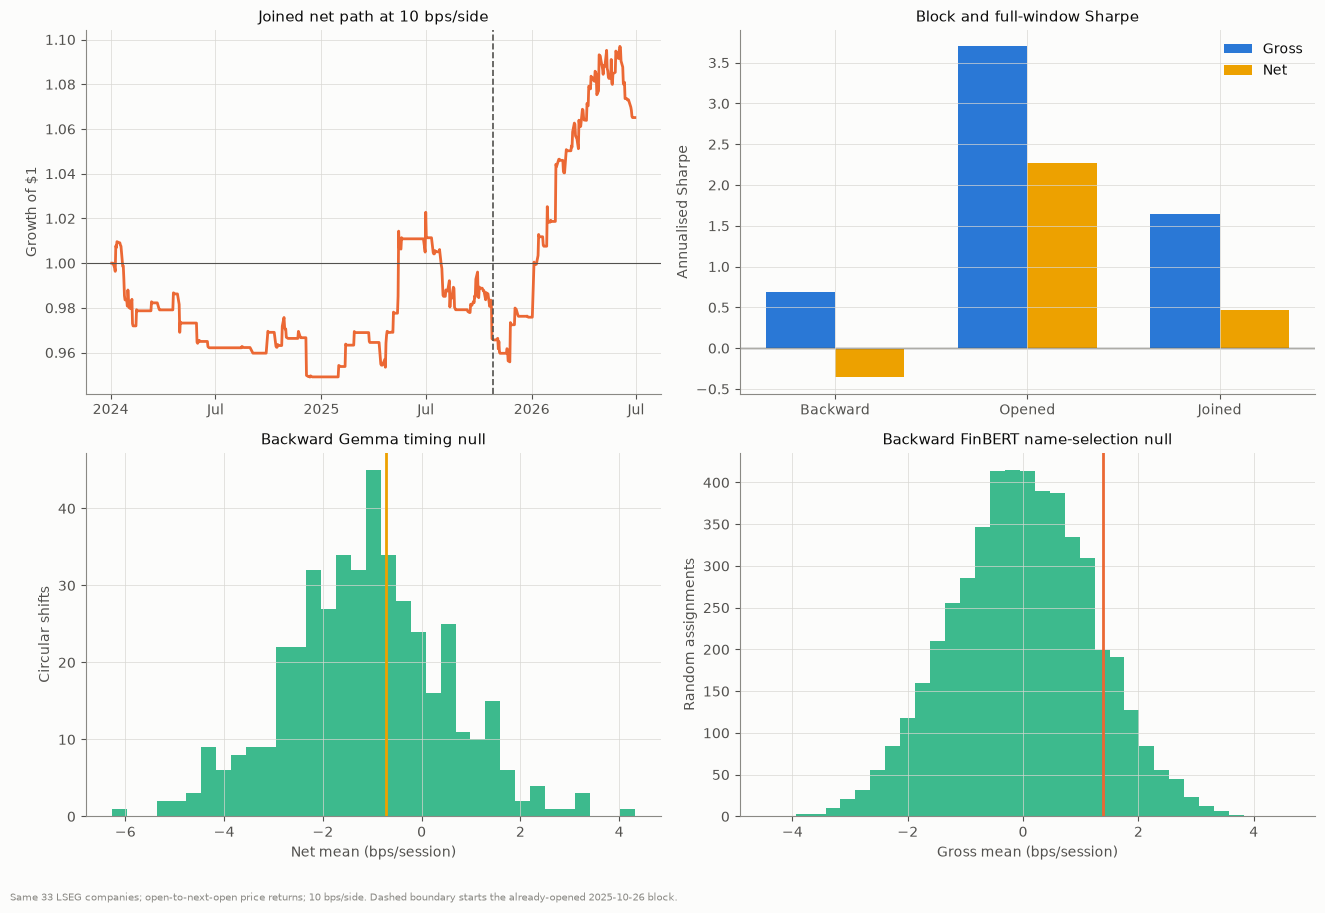

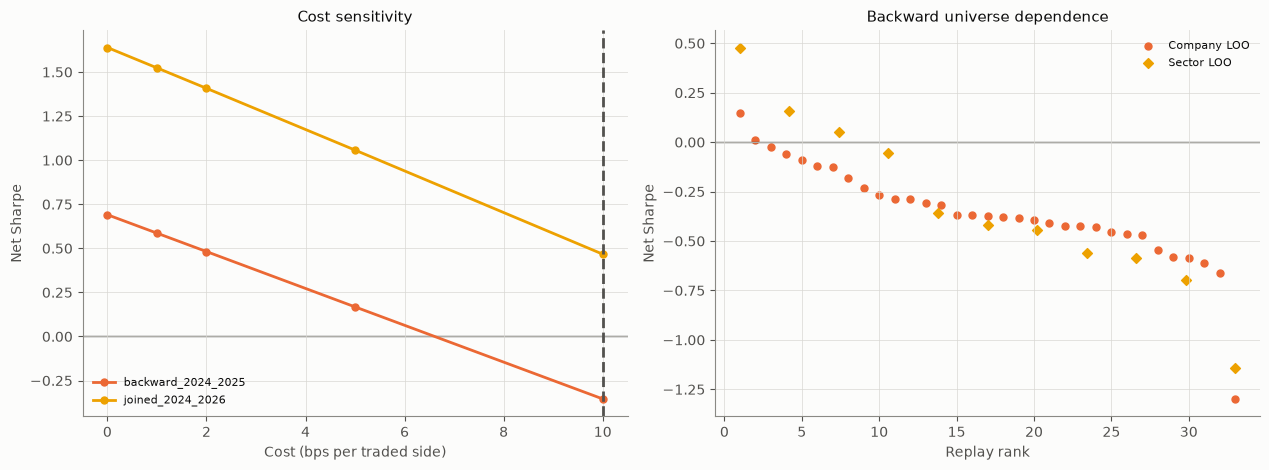

In [8]:
backward_cash = cash_inference.set_index("window").loc["backward_2024_2025"]
backward_factor = factor_results.set_index(["window", "model"]).loc[
    ("backward_2024_2025", "sector_spanning")
]
backward_halves = temporal.loc[temporal["window"].eq("backward_2024_2025")].set_index("period")
population_gate = bool(
    backward_summary["complete_sessions"] >= MINIMUM_SESSIONS
    and backward_summary["active_sessions"] >= MINIMUM_ACTIVE_SESSIONS
    and (backward_halves["active_sessions"] >= MINIMUM_ACTIVE_PER_HALF).all()
)
cash_gate = bool(
    backward_cash["mean_difference"] > 0
    and backward_cash["ci_low"] > 0
    and backward_cash["p_two_sided"] < 0.05
)
quality_gate = bool(
    backward_summary["total_return_net"] > 0
    and backward_summary["breakeven_bps_per_side"] > COST_BPS
    and (backward_halves["sharpe_net"] > 0).all()
)
factor_gate = bool(
    backward_factor["alpha_ci_low_bps_session"] > 0
    and backward_factor["alpha_p_two_sided_hac5"] < 0.05
)
dependence_gate = bool(
    dependence.loc[0, "positive_company_returns"] == dependence.loc[0, "company_replays"]
    and dependence.loc[0, "positive_sector_returns"] == dependence.loc[0, "sector_replays"]
)
mechanism_gate = bool(
    mechanism_inference["bh_reject_q05"].all()
    and mechanism_inference["observed_minus_null_bps_session"].gt(0).all()
)

gates = pd.DataFrame(
    [
        {
            "population_gate": population_gate,
            "cash_gate": cash_gate,
            "strategy_quality_gate": quality_gate,
            "sector_factor_alpha_gate": factor_gate,
            "dependence_gate": dependence_gate,
            "timing_and_name_mechanism_gate": mechanism_gate,
            "original_gemma_drift_gate": False,
            "qualifies_as_predeclared_replication": False,
            "prospective_or_deployment_claim": False,
            "all_return_gates_pass_excluding_drift": bool(
                population_gate and cash_gate and quality_gate and factor_gate and dependence_gate and mechanism_gate
            ),
        }
    ]
)
display(gates.T)

fig, axes = plt.subplots(2, 2, figsize=(13.2, 8.8))
joined = runs["joined_2024_2026"]
joined_equity = (1.0 + joined.daily["net_return"]).cumprod()
axes[0, 0].plot(joined.daily["return_end_date"], joined_equity, color=CATEGORICAL[1], lw=2.0)
axes[0, 0].axvline(boundary_naive, color=INK["reference"], ls="--", lw=1.2)
axes[0, 0].axhline(1.0, color=INK["reference"], lw=0.8)
axes[0, 0].set_ylabel("Growth of $1")
axes[0, 0].set_title("Joined net path at 10 bps/side")
date_locator = mdates.AutoDateLocator(minticks=5, maxticks=8)
axes[0, 0].xaxis.set_major_locator(date_locator)
axes[0, 0].xaxis.set_major_formatter(mdates.ConciseDateFormatter(date_locator))

bar = window_results.set_index("window").loc[list(runs)]
x = np.arange(len(bar))
width = 0.36
axes[0, 1].bar(x - width / 2, bar["sharpe_gross"], width, label="Gross", color=CATEGORICAL[0])
axes[0, 1].bar(x + width / 2, bar["sharpe_net"], width, label="Net", color=CATEGORICAL[3])
zero_line(axes[0, 1])
axes[0, 1].set_xticks(x, ["Backward", "Opened", "Joined"])
axes[0, 1].set_ylabel("Annualised Sharpe")
axes[0, 1].set_title("Block and full-window Sharpe")
axes[0, 1].legend(frameon=False)

axes[1, 0].hist(timing_null["mean_net"] * 10_000, bins=35, color=CATEGORICAL[2], alpha=0.85)
axes[1, 0].axvline(backward_summary["mean_net"] * 10_000, color=CATEGORICAL[3], lw=2.0)
axes[1, 0].set_xlabel("Net mean (bps/session)")
axes[1, 0].set_ylabel("Circular shifts")
axes[1, 0].set_title("Backward Gemma timing null")

axes[1, 1].hist(random_means * 10_000, bins=35, color=CATEGORICAL[2], alpha=0.85)
axes[1, 1].axvline(actual_gross_mean * 10_000, color=CATEGORICAL[1], lw=2.0)
axes[1, 1].set_xlabel("Gross mean (bps/session)")
axes[1, 1].set_ylabel("Random assignments")
axes[1, 1].set_title("Backward FinBERT name-selection null")

fig.tight_layout()
annotate_source(
    fig,
    "Same 33 LSEG companies; open-to-next-open price returns; 10 bps/side. "
    "Dashed boundary starts the already-opened 2025-10-26 block.",
)
fig.savefig(OUTPUT_DIR / "joined_path_and_mechanism_nulls.png", dpi=170, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
for name, colour in (("backward_2024_2025", CATEGORICAL[1]), ("joined_2024_2026", CATEGORICAL[3])):
    line = cost_curve.loc[cost_curve["window"].eq(name)]
    axes[0].plot(line["cost_bps_per_side"], line["sharpe_net"], marker="o", color=colour, label=name)
axes[0].axvline(COST_BPS, color=INK["reference"], ls="--")
zero_line(axes[0])
axes[0].set_xlabel("Cost (bps per traded side)")
axes[0].set_ylabel("Net Sharpe")
axes[0].set_title("Cost sensitivity")
axes[0].legend(frameon=False, fontsize=8)

company_rank = company_loo["sharpe_net"].sort_values(ascending=False).reset_index(drop=True)
sector_rank = sector_loo["sharpe_net"].sort_values(ascending=False).reset_index(drop=True)
axes[1].scatter(np.arange(1, len(company_rank) + 1), company_rank, color=CATEGORICAL[1], label="Company LOO")
axes[1].scatter(np.linspace(1, len(company_rank), len(sector_rank)), sector_rank, color=CATEGORICAL[3], marker="D", label="Sector LOO")
zero_line(axes[1])
axes[1].set_xlabel("Replay rank")
axes[1].set_ylabel("Net Sharpe")
axes[1].set_title("Backward universe dependence")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cost_and_dependence.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate evidence

No headline text or row-level scorer output is written here. The manifest
records that the joined analysis is descriptive and cannot rescue the failed
drift gate.

In [9]:
population_summary.to_csv(OUTPUT_DIR / "population_summary.csv", index=False)
join_summary.to_csv(OUTPUT_DIR / "join_summary.csv", index=False)
panel_coverage.to_csv(OUTPUT_DIR / "panel_coverage.csv", index=False)
reproduction.to_csv(OUTPUT_DIR / "recent_input_reproduction.csv", index=False)
window_results.to_csv(OUTPUT_DIR / "window_results.csv", index=False)
temporal.to_csv(OUTPUT_DIR / "temporal_results.csv", index=False)
calendar_results.to_csv(OUTPUT_DIR / "calendar_results.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
cash_inference.to_csv(OUTPUT_DIR / "cash_inference.csv", index=False)
factor_results.to_csv(OUTPUT_DIR / "factor_results.csv", index=False)
mechanism_inference.to_csv(OUTPUT_DIR / "mechanism_inference.csv", index=False)
timing_null.to_csv(OUTPUT_DIR / "timing_shift_null.csv", index=False)
company_loo.to_csv(OUTPUT_DIR / "leave_one_company_out.csv", index=False)
sector_loo.to_csv(OUTPUT_DIR / "leave_one_sector_out.csv", index=False)
dependence.to_csv(OUTPUT_DIR / "dependence_summary.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
for name, run in runs.items():
    run.daily.to_parquet(OUTPUT_DIR / f"{name}_daily.parquet", index=False)
for population_name, scorer_panels in panels.items():
    for scorer, panel in scorer_panels.items():
        panel.to_parquet(OUTPUT_DIR / f"{population_name}_{scorer}_firm_open.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

manifest = {
    "status": "POST_DRIFT_STOP_JOINED_LONG_WINDOW_MEASUREMENT_SENSITIVITY",
    "notebook": "67_lseg_gemma_finbert_joined_long_window.ipynb",
    "git_commit_at_execution": git_commit,
    "frozen_spec": "final_experiments/frozen_specs/lseg_gemma_finbert_hybrid_joined_long_window_v1.json",
    "completeness_amendment": "final_experiments/frozen_specs/lseg_gemma_finbert_hybrid_joined_long_window_completeness_amendment_20260812.json",
    "seed": SEED,
    "inputs": {
        "score_join": score_audit,
        "price_path": str(PRICE_PATH.relative_to(REPO_ROOT)),
        "price_sha256": sha256_file(PRICE_PATH),
        "licensed_headline_text_loaded": False,
        "row_level_scores_written": False,
    },
    "strategy": {
        "candidate": "unchanged Notebook 36 equal-weight Gemma-timing/FinBERT-ranking hybrid",
        "universe": "immutable original 33",
        "single_name_cap": SINGLE_NAME_CAP,
        "holding_intervals": 1,
        "cost_bps_per_traded_side": COST_BPS,
        "bootstrap": {
            "replications": BOOTSTRAP_REPLICATIONS,
            "block_length": BLOCK_LENGTH,
        },
        "mechanisms": {
            "circular_shifts": len(timing_null),
            "conditional_random_names": NAME_RANDOMISATIONS,
            "multiplicity": "two one-sided mechanism tests; BH-FDR q=0.05",
        },
    },
    "population": json.loads(population_summary.to_json(orient="records", date_format="iso")),
    "completeness": {
        name: {
            "complete_sessions": int(run.target_audit["complete_session"].sum()),
            "incomplete_sessions_forced_cash": int((~run.target_audit["complete_session"]).sum()),
            "incomplete_session_dates": [
                str(pd.Timestamp(value).date())
                for value in run.target_audit.loc[
                    ~run.target_audit["complete_session"], "session_date"
                ]
            ],
        }
        for name, run in runs.items()
    },
    "join": json.loads(join_summary.to_json(orient="records"))[0],
    "results": json.loads(window_results.to_json(orient="records")),
    "cash_inference": json.loads(cash_inference.to_json(orient="records")),
    "factor_results": json.loads(factor_results.to_json(orient="records")),
    "temporal": json.loads(temporal.to_json(orient="records")),
    "calendar": json.loads(calendar_results.to_json(orient="records")),
    "mechanisms": json.loads(mechanism_inference.to_json(orient="records")),
    "dependence": json.loads(dependence.to_json(orient="records"))[0],
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "claim_boundary": {
        "original_drift_gate_remains_failed": True,
        "qualifies_as_predeclared_replication": False,
        "joined_window_is_descriptive": True,
        "prospective_or_deployment_claim": False,
        "retuning_permitted": False,
    },
    "limitations": [
        "the exact-endpoint drift audit failed 0.7881 versus the frozen 0.80 minimum",
        "the full joined path includes the already-opened strategy-selection interval",
        "the earlier block was collected and scored after the later strategy result was known",
        "cross-block duplicate scores can differ because the hosted Gemma route is not weight-pinned and FinBERT floating-point execution can differ",
        "raw next-open returns exclude dividends",
        "headline-only all-source LSEG retrieval has no human relevance or sentiment audit",
        "this analysis cannot promote the strategy regardless of its return result",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "POST_DRIFT_STOP_JOINED_LONG_WINDOW_MEASUREMENT_SENSITIVITY",
  "notebook": "67_lseg_gemma_finbert_joined_long_window.ipynb",
  "git_commit_at_execution": "ac1b90fb1c2c1b9760b6da3258d8e9dc39d481e4",
  "frozen_spec": "final_experiments/frozen_specs/lseg_gemma_finbert_hybrid_joined_long_window_v1.json",
  "completeness_amendment": "final_experiments/frozen_specs/lseg_gemma_finbert_hybrid_joined_long_window_completeness_amendment_20260812.json",
  "seed": 20260820,
  "inputs": {
    "score_join": {
      "backward": {
        "paired_unique_headlines": 1219608,
        "population_sha256": "68b987095715fc3ecca8d80056487f82b3e250094e2a6c3e986afa812cd449c7",
        "finbert": {
          "scorer": "finbert",
          "rows_including_historical_attempts": 1219608,
          "status_counts": {
            "success": 1219608
          },
          "unique_successes": 1219608,
          "duplicate_successes": 0,
          "invalid_success_probabilities": 0,
          "reported_c

## Decision

The decision is generated from the executed tables above. A favourable
backward or joined return path is only exploratory sensitivity evidence; an
adverse path is evidence against temporal robustness. In either case, the
original endpoint-drift stop remains correctly recorded and the untouched
post-2026-06-26 prospective block remains the only route to a future
prospective claim.

In [10]:
backward_result = window_results.set_index("window").loc["backward_2024_2025"]
joined_result = window_results.set_index("window").loc["joined_2024_2026"]
display(
    Markdown(
        "\n".join(
            [
                "### Result",
                "",
                f"- **Backward 2024–2025:** {int(backward_result['complete_sessions'])} complete sessions "
                f"plus {int(backward_result['incomplete_cash_sessions'])} forced-cash sessions; "
                f"gross/net Sharpe **{backward_result['sharpe_gross']:.3f}/"
                f"{backward_result['sharpe_net']:.3f}**, net return "
                f"**{backward_result['total_return_net']:+.2%}**, and break-even "
                f"**{backward_result['breakeven_bps_per_side']:.2f} bps/side**.",
                f"- **Uncertainty and controls:** cash interval "
                f"**[{backward_cash['ci_low'] * 10_000:+.2f}, "
                f"{backward_cash['ci_high'] * 10_000:+.2f}] bps/session** "
                f"(p={backward_cash['p_two_sided']:.4f}); sector-factor alpha "
                f"**{backward_factor['alpha_bps_session']:+.2f} bps/session** "
                f"[**{backward_factor['alpha_ci_low_bps_session']:+.2f}, "
                f"{backward_factor['alpha_ci_high_bps_session']:+.2f}**]. "
                f"Only {int(dependence.loc[0, 'positive_company_returns'])}/"
                f"{int(dependence.loc[0, 'company_replays'])} company and "
                f"{int(dependence.loc[0, 'positive_sector_returns'])}/"
                f"{int(dependence.loc[0, 'sector_replays'])} sector exclusions remain profitable.",
                f"- **Joined descriptive path:** gross/net Sharpe "
                f"**{joined_result['sharpe_gross']:.3f}/{joined_result['sharpe_net']:.3f}** "
                f"and net return **{joined_result['total_return_net']:+.2%}** over "
                f"{int(joined_result['n_sessions'])} sessions. This positive full path masks the "
                "negative earlier block and the already-opened strong recent block.",
                "- **Decision:** historical robustness is rejected. Every backward return, factor, "
                "dependence, and mechanism gate fails. The original Gemma drift failure remains "
                "binding, so this is not the preregistered replication, prospective evidence, "
                "or permission to retune.",
            ]
        )
    )
)

### Result

- **Backward 2024–2025:** 445 complete sessions plus 11 forced-cash sessions; gross/net Sharpe **0.691/-0.354**, net return **-3.43%**, and break-even **6.60 bps/side**.
- **Uncertainty and controls:** cash interval **[-3.47, +2.03] bps/session** (p=0.6122); sector-factor alpha **-1.06 bps/session** [**-3.55, +1.43**]. Only 1/33 company and 3/11 sector exclusions remain profitable.
- **Joined descriptive path:** gross/net Sharpe **1.639/0.467** and net return **+6.51%** over 623 sessions. This positive full path masks the negative earlier block and the already-opened strong recent block.
- **Decision:** historical robustness is rejected. Every backward return, factor, dependence, and mechanism gate fails. The original Gemma drift failure remains binding, so this is not the preregistered replication, prospective evidence, or permission to retune.